# This project demonstrates the psychological signal compression technique using Autoencoder

This section imports all required libraries for ECG signal processing, compression techniques, deep learning (Autoencoder), evaluation metrics, and visualization.

In [ ]:
import os
import glob
import bz2
import lzma
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import pickle
from tensorflow.keras.layers import Dense, Input, Add, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
from sklearn.decomposition import PCA

Defines the combined loss function used during training, which integrates Mean Squared Error (MSE) and Mean Absolute Error (MAE) to improve reconstruction quality.

In [ ]:
def combined_loss(y_true, y_pred):
    """Custom loss function used during training."""
    mse = K.mean(K.square(y_true - y_pred))
    mae = K.mean(K.abs(y_true - y_pred))
    return mse + mae


This section defines evaluation metrics used to assess compression performance, including MSE, MAE, PRD, RMS, and a quality score.

In [ ]:
def compute_metrics(original, reconstructed):
    """Compute reconstruction quality metrics."""
    o = np.nan_to_num(original)
    r = np.nan_to_num(reconstructed)

    mse = np.mean((o - r) ** 2)
    mae = np.mean(np.abs(o - r))
    prd = 100 * sqrt(np.sum((o - r) ** 2) / (np.sum(o ** 2) + 1e-12))
    rms = sqrt(mse)
    quality = 1 - (np.linalg.norm(o - r) /
                   (np.linalg.norm(o) + 1e-8))

    return mse, mae, prd, rms, quality

The ECG signal is divided into fixed-size blocks to match the input requirements of the autoencoder model.

In [ ]:
def create_blocks(signal, block_size=36):
    """Segment ECG signal into fixed-length blocks."""
    n = len(signal) // block_size
    return signal[:n * block_size].reshape(n, block_size)

Defines the deep autoencoder network used for ECG compression, consisting of an encoder, latent representation, and decoder with regularization techniques.

In [ ]:
def AutoEncoderModel():
  # =======================================================
  # 4️⃣ Define the Autoencoder Architecture
  # =======================================================
  L2_REG, DROPOUT, LATENT = 1e-5, 0.1, 2
  inp = Input(shape=(36,))

  x = Dense(32, activation='relu', kernel_regularizer=l2(L2_REG))(inp)
  x = BatchNormalization()(x)
  x = Dropout(DROPOUT)(x)

  x = Dense(26, activation='relu', kernel_regularizer=l2(L2_REG))(x)
  x = BatchNormalization()(x)
  x = Dropout(DROPOUT)(x)

  x = Dense(20, activation='relu', kernel_regularizer=l2(L2_REG))(x)
  x = BatchNormalization()(x)
  x = Dense(16, activation='relu', kernel_regularizer=l2(L2_REG))(x)
  x = BatchNormalization()(x)
  x = Dropout(DROPOUT)(x)

  x = Dense(8, activation='relu', kernel_regularizer=l2(L2_REG))(x)
  x = Dense(4, activation='relu', kernel_regularizer=l2(L2_REG))(x)
  latent = Dense(LATENT, activation='linear', name='latent')(x)

  x = Dense(4, activation='relu')(latent)
  x = Dense(8, activation='relu')(x)
  x = Dense(16, activation='relu')(x)
  x = Dense(20, activation='relu')(x)
  x = Dense(26, activation='relu')(x)
  x = Dense(32, activation='relu')(x)
  decoded = Dense(36, activation='linear')(x)

  out = Add()([decoded, inp])
  autoencodermodel = Model(inp, out)
  return autoencodermodel


Loads the trained autoencoder weights from Google Drive to perform compression without retraining.

In [ ]:
autoencoder = AutoEncoderModel()
print(autoencoder.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 32)        │      1,184 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_13[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 26)        │        858 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 26)        │        104 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 26)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 20)        │        540 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20)        │         80 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 16)        │        336 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_16[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 16)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 8)         │        136 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 4)         │         36 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent (Dense)      │ (None, 2)         │         10 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 4)         │         12 │ latent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 8)         │         40 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 16)        │        144 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 20)        │        340 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 26)        │        546 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 32)        │        864 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 36)        │      1,188 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,610 (25.82 KB)

 Trainable params: 6,422 (25.09 KB)

 Non-trainable params: 188 (752.00 B)

None


Loads the trained autoencoder weights from Google Drive to perform compression without retraining.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/My Drive/ecg_autoencoder_model.h5"
autoencoder.load_weights(MODEL_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loads ECG data from a CSV file, extracts the relevant signal column, converts the signal into fixed-size blocks, and normalizes it using training statistics to ensure reliable compression and reconstruction performance.

In [ ]:
signal_path = "/content/drive/My Drive/sample_ecg.csv"
signals = []
df = pd.read_csv(signal_path)
df.columns = df.columns.str.strip().str.upper()

cols = [c for c in df.columns if "MLII" in c or "ECG" in c or "V1" in c]
if not cols:
    raise ValueError("No ECG column found in file.")

vals = pd.to_numeric(df[cols[0]], errors='coerce').dropna().values
signal_train = vals.astype(np.float32)[:500000]

# Create blocks
X_train_blocks = create_blocks(signal_train, 36).astype(np.float32)

# Compute normalization stats
mean_train = X_train_blocks.mean()
std_train = X_train_blocks.std() + 1e-8

# Normalize blocks
X_train_norm = (X_train_blocks - mean_train) / std_train

Implements multiple compression methods — Autoencoder, PCA, BZIP2, and LZMA — to reconstruct the ECG signal and trims the outputs to match the original signal length for accurate and fair evaluation.

In [ ]:
# AE reconstruction (normalized -> unnormalize)
recon_train_norm = autoencoder.predict(X_train_norm, verbose=0)
recon_train = (recon_train_norm - 0.0) * std_train + mean_train   # bring back to original scale
recon_train_flat = recon_train.flatten()

# PCA on normalized blocks (then unnormalize)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_norm)
X_pca_rec_norm = pca.inverse_transform(X_pca)
X_pca_rec = (X_pca_rec_norm * std_train + mean_train).flatten()

# BZ2 / LZMA on raw bytes (use float32 bytes)
signal_train_f32 = signal_train.astype(np.float32)
sig_bytes = signal_train_f32.tobytes()
comp_bz2 = bz2.compress(sig_bytes)
comp_lzma = lzma.compress(sig_bytes)
dec_bz2 = np.frombuffer(bz2.decompress(comp_bz2), dtype=np.float32)
dec_lzma = np.frombuffer(lzma.decompress(comp_lzma), dtype=np.float32)

# Trim arrays to same length
min_len = min(len(signal_train_f32), len(recon_train_flat), len(X_pca_rec), len(dec_bz2), len(dec_lzma))
orig_train_trim = signal_train_f32[:min_len]
recon_train_flat = recon_train_flat[:min_len]
X_pca_rec = X_pca_rec[:min_len]
dec_bz2 = dec_bz2[:min_len]
dec_lzma = dec_lzma[:min_len]

Visualizes the original ECG signal alongside reconstructed signals from each compression method.

/tmp/ipython-input-228/3931656327.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(orig, 'k', label="Original", color='#969696')


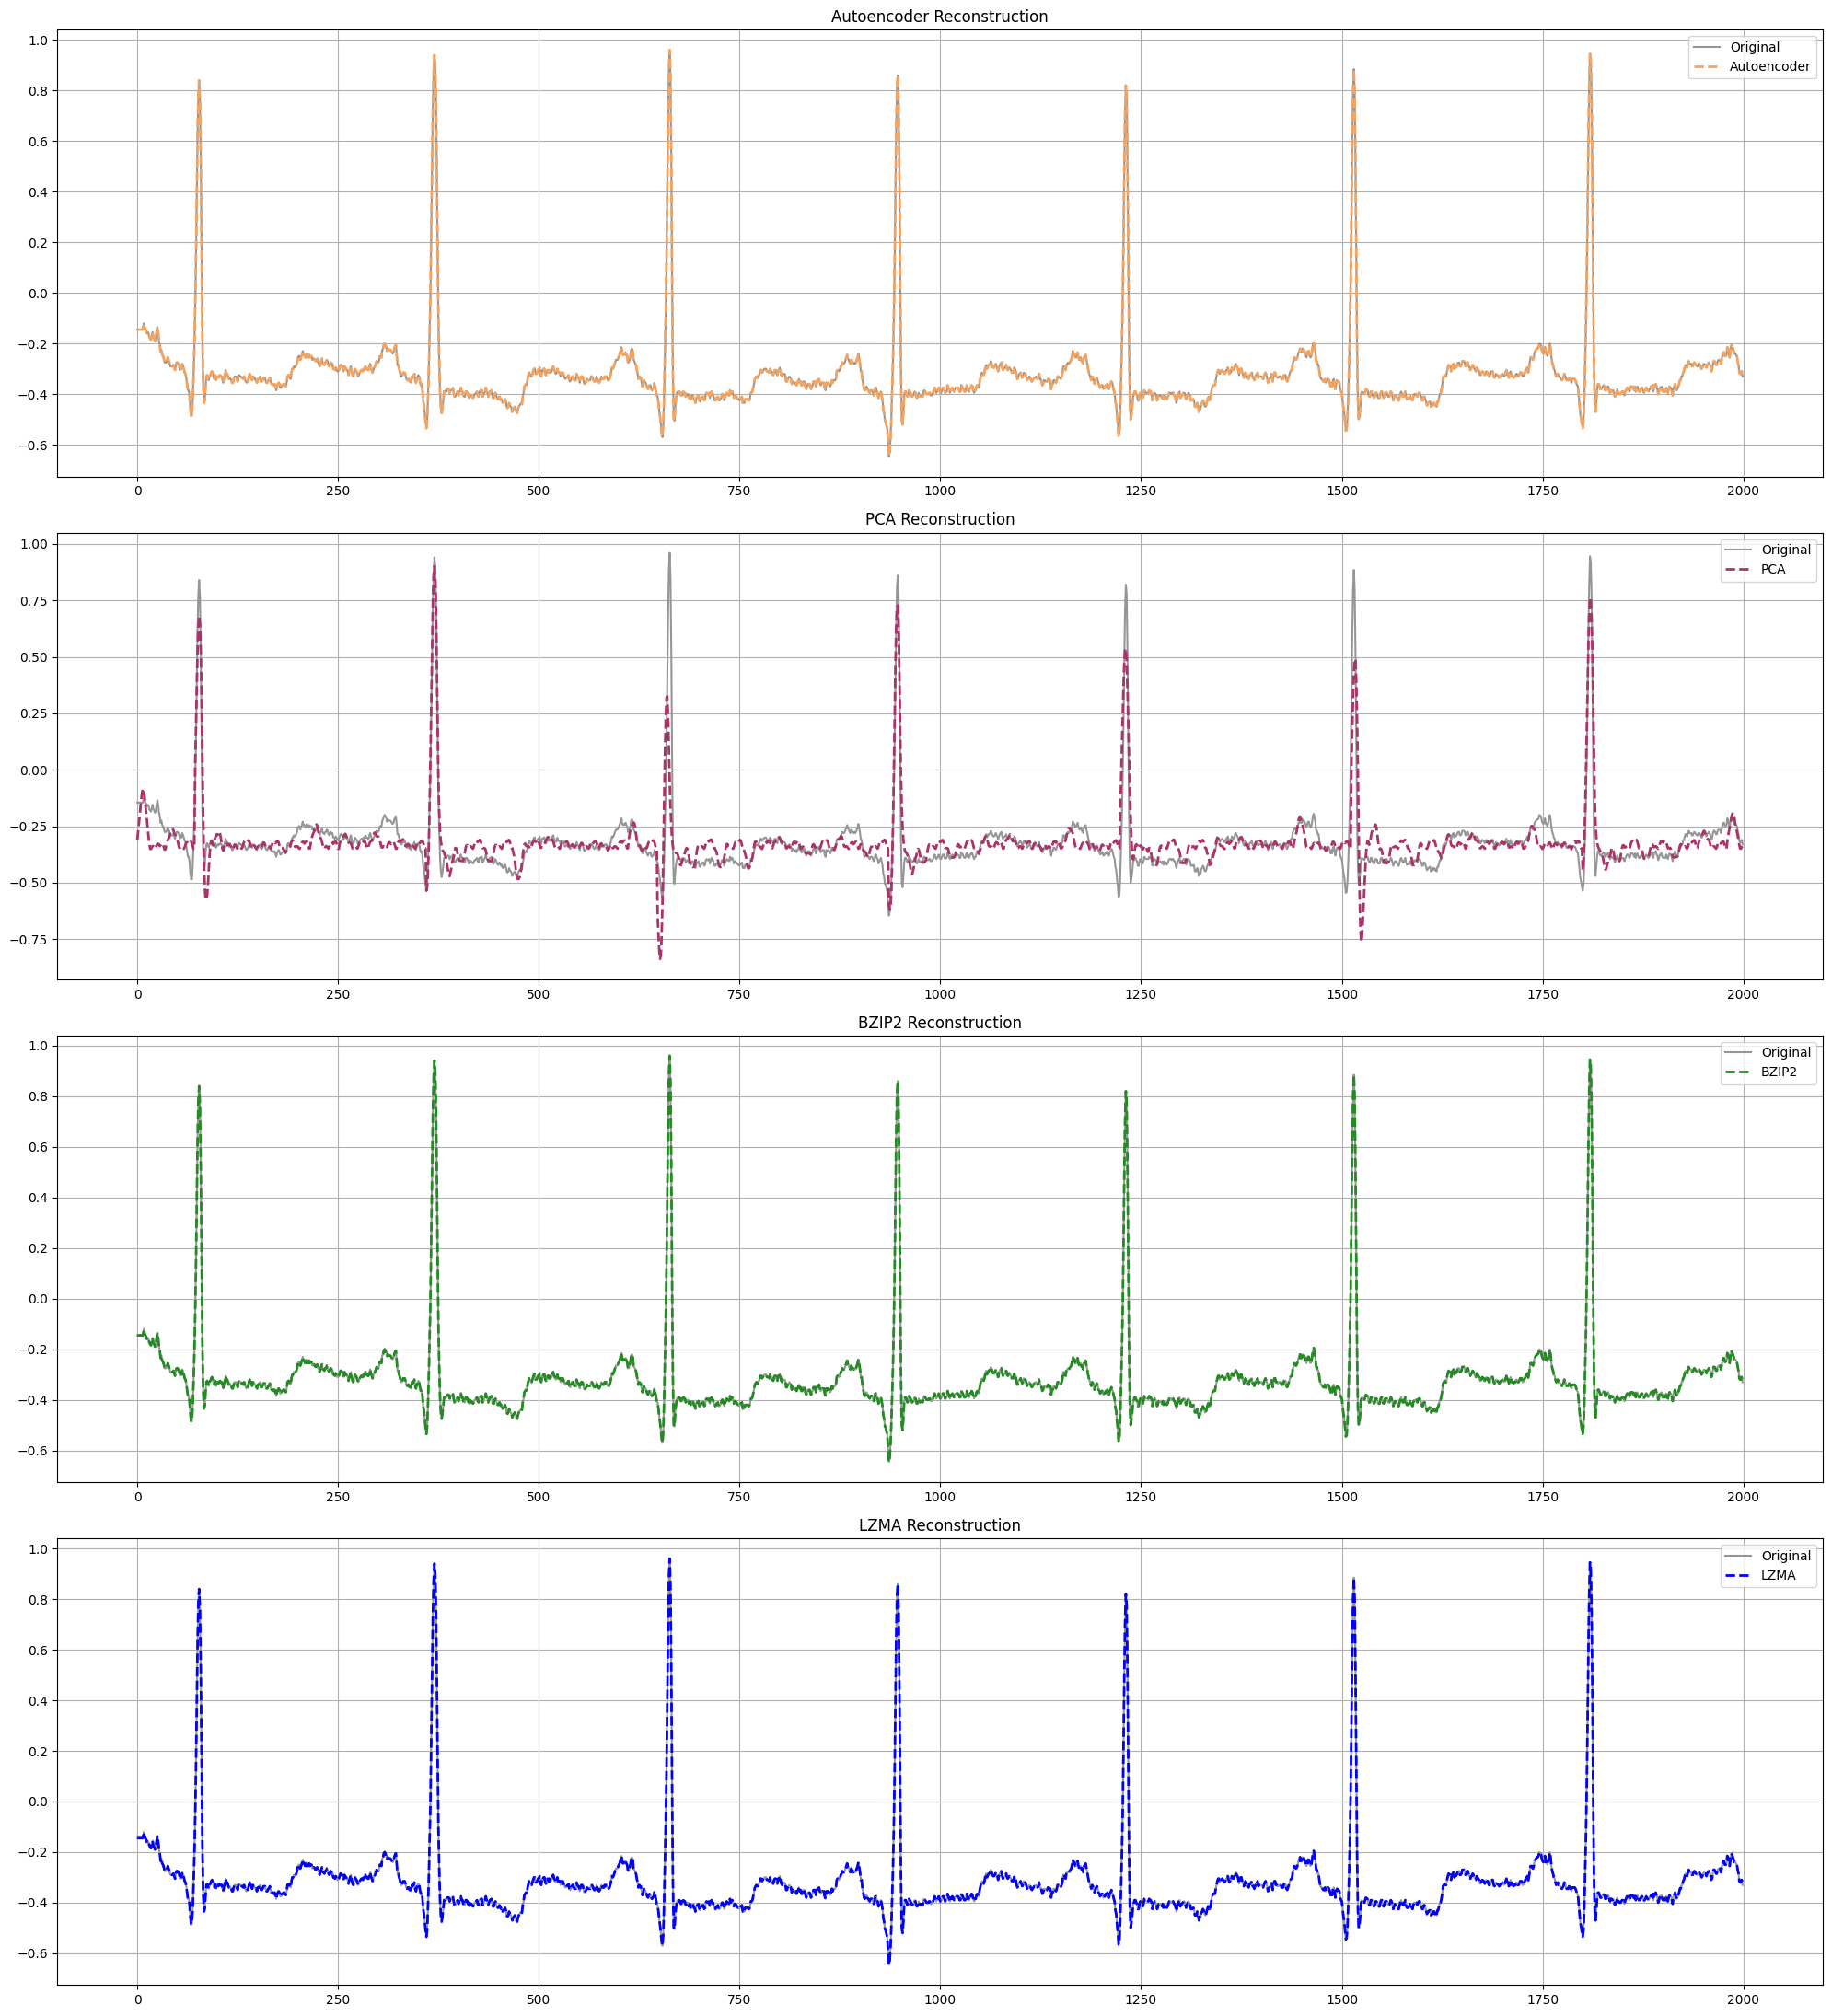

In [ ]:
L = 2000   # number of samples to display

orig = signal_train[:L]
ae = recon_train_flat[:L]
pca_out = X_pca_rec[:L]
bz_out = dec_bz2[:L]
lz_out = dec_lzma[:L]

plt.figure(figsize=(20, 22))

methods = [
    ("Autoencoder", ae, '#F4A460'),
    ("PCA", pca_out, '#AA336A'),
    ("BZIP2", bz_out, '#228B22'),
    ("LZMA", lz_out, '#0000FF'),
]

for i, (name, rec, color) in enumerate(methods, 1):
    plt.subplot(4, 1, i)
    plt.plot(orig, 'k', label="Original", color='#969696')
    plt.plot(rec, '--', color=color, label=name, linewidth=2)
    plt.title(name + " Reconstruction")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()
